In [ ]:
#This notebook builds a weekly avocado price forecasting model for the U.S. market 
using Facebook's Prophet library. By analyzing historical price trends from 2015 to 2018, 
AvoCast helps retailers, growers, and wholesalers make smarter decisions about 
stock management, pricing strategy, and promotions.

**Region:** TotalUS  
**Model:** Facebook Prophet  
**Evaluation Metrics:** MAE, MAPE

In [ ]:
## 1. Environment Setup
Installing all required libraries for data processing, visualization, and forecasting.

In [2]:
## 2. Import Libraries

In [16]:

pip install pandas matplotlib seaborn prophet scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Core libraries for data manipulation, visualization, and time-series forecasting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
import numpy as np

In [18]:
import os
print(os.getcwd())

C:\Users\umuha\Downloads\DLBAIBEPAIPC01-Project-AI-Product-Commercialisation\AvoCast-Jupyter-Notebook


In [ ]:
## 3. Load & Explore Data
## Task: Load avocado.csv from Kaggle using pandas. Review columns such as date, 
## average price, type, and region. Choose one region (e.g., TotalUS). 
## Comment: Loading the avocado dataset and filtering for TotalUS region to capture 
## national price trends. We then explore the structure and check for missing values. 

In [19]:
# Load raw avocado pricing data — weekly entries from 2015 to 2018 across U.S. regions
df = pd.read_csv("avocado.csv")
# Filter for TotalUS only — national data gives the most complete price signal
df = df[df['region'] == 'TotalUS']
df.head()


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
2652,0,2015-12-27,0.95,27297983.67,9626901.09,10197890.05,1184340.09,6288852.44,4850404.09,1252626.31,185822.04,conventional,2015,TotalUS
2653,1,2015-12-20,0.98,25083647.17,8710021.76,9329861.85,1201020.01,5842743.55,4618389.66,1025048.77,199305.12,conventional,2015,TotalUS
2654,2,2015-12-13,0.93,28041335.38,9855053.66,10805838.91,1016163.17,6364279.64,4964462.13,1371440.28,28377.23,conventional,2015,TotalUS
2655,3,2015-12-06,0.89,28800396.57,9405464.36,12160838.62,931830.63,6302262.96,5005077.36,1233956.21,63229.39,conventional,2015,TotalUS
2656,4,2015-11-29,0.99,22617999.38,8094803.56,9003178.41,731008.41,4789009.00,3901953.04,856560.34,30495.62,conventional,2015,TotalUS


In [ ]:
##  Prepare for Prophet
## Task: Rename your date column to ds and target column (price) to y. Sort chronologically, 
## fill in any missing dates, and resample to weekly frequency if needed.

In [20]:
print("The column name before renaming : ", df.columns)
df = df.rename(columns = {'Date': 'ds', 'AveragePrice': 'y'})
print("The column name after renaming : ", df.columns)

#prophet only works if the date column is in proper datetime format thats why I convert the Date type

df['ds'] = pd.to_datetime(df['ds'])
df.head()

The column name before renaming :  Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='str')
The column name after renaming :  Index(['Unnamed: 0', 'ds', 'y', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='str')


,Unnamed: 0,ds,y,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
2652,0,2015-12-27,0.95,27297983.67,9626901.09,10197890.05,1184340.09,6288852.44,4850404.09,1252626.31,185822.04,conventional,2015,TotalUS
2653,1,2015-12-20,0.98,25083647.17,8710021.76,9329861.85,1201020.01,5842743.55,4618389.66,1025048.77,199305.12,conventional,2015,TotalUS
2654,2,2015-12-13,0.93,28041335.38,9855053.66,10805838.91,1016163.17,6364279.64,4964462.13,1371440.28,28377.23,conventional,2015,TotalUS
2655,3,2015-12-06,0.89,28800396.57,9405464.36,12160838.62,931830.63,6302262.96,5005077.36,1233956.21,63229.39,conventional,2015,TotalUS
2656,4,2015-11-29,0.99,22617999.38,8094803.56,9003178.41,731008.41,4789009.00,3901953.04,856560.34,30495.62,conventional,2015,TotalUS


In [21]:
# sort the data chronologically by date column 'ds'
df = df.sort_values('ds')
df.head()



,Unnamed: 0,ds,y,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
2703,51,2015-01-04,0.95,31324277.73,12357161.34,13624083.05,844093.32,4498940.02,3585321.58,894945.63,18672.81,conventional,2015,TotalUS
11829,51,2015-01-04,1.46,612910.15,233286.13,216611.20,4370.99,158641.83,115068.71,43573.12,0.00,organic,2015,TotalUS
2702,50,2015-01-11,1.01,29063542.75,11544810.53,12134773.38,866574.66,4517384.18,3783261.16,718333.87,15789.15,conventional,2015,TotalUS
11828,50,2015-01-11,1.42,669528.88,270966.74,260971.60,3830.42,133760.12,106844.49,26915.63,0.00,organic,2015,TotalUS
2701,49,2015-01-18,1.03,29043458.85,11858139.34,11701947.80,831301.90,4652069.81,3873041.26,771093.20,7935.35,conventional,2015,TotalUS


In [22]:
# set date as index as it is needed for resampling
df = df.set_index('ds')

# check do we have duplicates on the date/ds column then we can aggregate the column by 
#group date and take mean price
print(df.index.duplicated().sum())

# yes, the index column has 169 duplicate records
df = df.groupby('ds')['y'].mean()
# fill missing dates as prophet need continuous time series without gap
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_range)

df.head()


169


2015-01-04    1.205
2015-01-05      NaN
2015-01-06      NaN
2015-01-07      NaN
2015-01-08      NaN
Freq: D, Name: y, dtype: float64

In [23]:
# handle missing value and I used here forward fill method because it is quite common 
# for price data to update the NaN value
df = df.ffill()
df.head()

2015-01-04    1.205
2015-01-05    1.205
2015-01-06    1.205
2015-01-07    1.205
2015-01-08    1.205
Freq: D, Name: y, dtype: float64

In [24]:
# resample to weekly frequency
df = df.resample('W').mean()
df = df.reset_index()
df = df.rename(columns={'index': 'ds'})
df.head()

,ds,y
0,2015-01-04,1.205000
1,2015-01-11,1.206429
2,2015-01-18,1.216429
3,2015-01-25,1.233571
4,2015-02-01,1.262143


In [25]:
#Tune the model: Fit a Prophet model using yearly and weekly seasonality. Add a holiday (e.g., 
#Thanksgiving). Hold out the last 20 percent of the data for testing. Report forecasting accuracy using MAE 
# and MAPE.
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

In [26]:
# Holidays
from prophet import Prophet

thanksgiving = pd.DataFrame({
    'holiday': 'thanksgiving',
    'ds': pd.to_datetime([
        '2015-11-26','2016-11-24','2017-11-23',
        '2018-11-22','2019-11-28','2020-11-26',
        '2021-11-25','2022-11-24'
    ]),
    'lower_window': 0,
    'upper_window': 1
})

# Model
model = Prophet(yearly_seasonality=True,
                weekly_seasonality=True,
                holidays=thanksgiving)

model.fit(train_df)

# Forecast
future = model.make_future_dataframe(periods=len(test_df), freq='W')
forecast = model.predict(future)

forecast_test = forecast[['ds','yhat']].iloc[-len(test_df):]

12:19:06 - cmdstanpy - INFO - Chain [1] start processing
12:19:06 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# Metrics
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(test_df['y'].values, forecast_test['yhat'].values)
mape = np.mean(np.abs((test_df['y'].values - forecast_test['yhat'].values) / test_df['y'].values)) * 100

print("MAE:", mae)
print("MAPE:", mape)

MAE: 0.13808762656237478
MAPE: 9.276390831704381


In [ ]:
## The model was configured with both yearly and weekly seasonality. 
## However, since the data was aggregated to weekly frequency, yearly seasonality captures 
## meaningful patterns while weekly seasonality has limited impact.

## The model achieved an MAE of 0.138, indicating that predictions deviate from actual avocado 
## prices by approximately 0.14 units on average. The MAPE of 9.28% suggests high forecasting accuracy,
## with predictions being within about 10% of actual values.

Text(87.59722222222221, 0.5, 'Price')

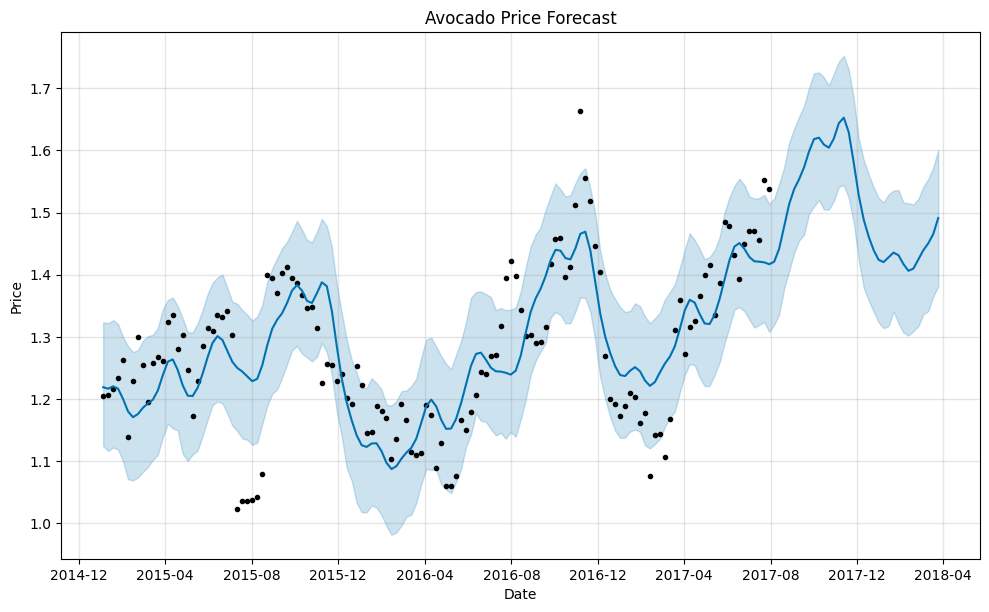

In [28]:
#Visualize & Explain: Plot the forecast, seasonal components, and change points. 
#In markdown, explain Prophet’s additive time-series model using plain language.
fig1 = model.plot(forecast)
ax = fig1.gca()
ax.set_title('Avocado Price Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

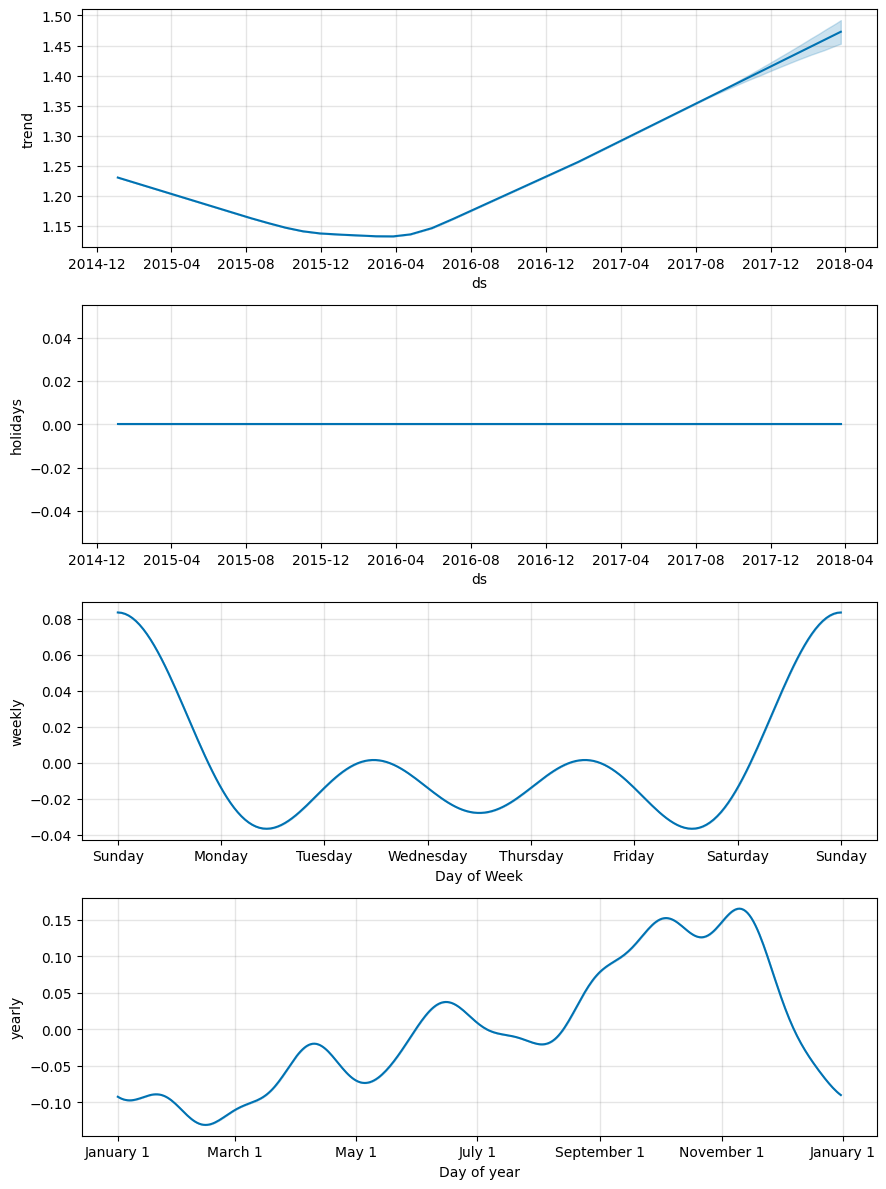

In [29]:
fig2 = model.plot_components(forecast)

Text(87.59722222222221, 0.5, 'Price')

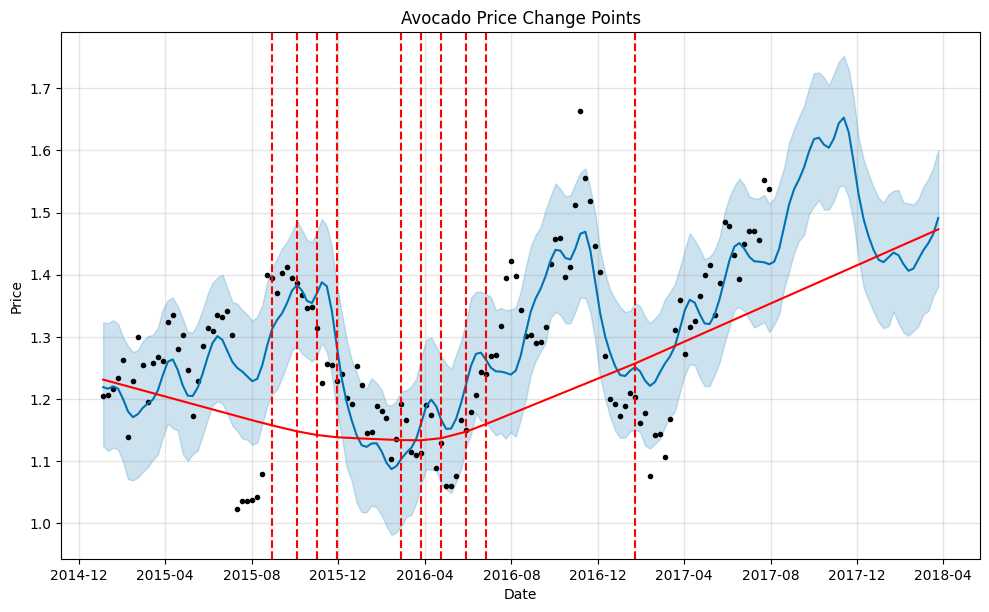

In [30]:
from prophet.plot import add_changepoints_to_plot

fig3 = model.plot(forecast)
a = add_changepoints_to_plot(fig3.gca(), model, forecast)
ax = fig3.gca()
ax.set_title('Avocado Price Change Points')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

In [ ]:
#In markdown, explain Prophet’s additive time-series model using plain language.

## The Prophet model is based on an additive time series framework, where the observed value is expressed as the combination of multiple components:
## y(t) = trend + seasonality + holidays + error
## In this formulation, each component contributes independently to the final prediction. The trend captures long-term changes in the data, seasonality reflects recurring patterns, holidays account for the effects of specific events, and the error term represents unexplained variation.
## A key strength of Prophet lies in its ability to automatically identify structural patterns within the data. The model detects changepoints — shifts in the underlying trend — as well as recurring seasonal effects, reducing the need for extensive manual tuning. In this project, several changepoints were identified, most notably during 2016 and 2017, corresponding to periods of significant market movement in avocado prices.
## Prophet also performs well under real-world data conditions: it is robust to missing observations, adapts to sudden trend changes, and handles strong seasonal patterns effectively. These properties make it well-suited to agricultural commodity data like avocado prices, where both seasonality and supply disruptions are common.
## In the context of this project, the model successfully captured the long-term price trajectory, yearly seasonal fluctuations, and the short-term uplift associated with Thanksgiving demand. This is reflected in the evaluation results, where the model achieved a MAE of 0.138 and a MAPE of 9.28% on the held-out test set — confirming that the theoretical strengths of Prophet translated into reliable forecasting performance in practice.

In [ ]:
## Task: Business Translation: List three concrete retailer actions based on your forecast 

## Business Translation: Retailer Actions Based on Forecast

## The forecast provides actionable insights that retailers can translate into strategic operational decisions.
## 1. Forward-buying inventory ahead of seasonal price increases
## The seasonal decomposition consistently identifies a price increase beginning in late spring and continuing through summer, with average prices rising from approximately $1.20 in March to over $1.40 by June. Retailers are therefore advised to build inventory buffers during February and early March, before the seasonal uplift takes effect. Securing stock at lower prices ahead of this window reduces average procurement costs and protects profit margins during the higher-price period — particularly relevant for large supermarket chains operating on thin margins.
## 2. Targeted promotions during the autumn price dip
## The model identifies a consistent seasonal decline in avocado prices between September and early October, when average prices reach their lowest annual levels. This window presents an optimal opportunity for retailers to run targeted promotional campaigns. Since procurement costs are lower during this period, promotions can be executed with a reduced impact on overall margin, while simultaneously stimulating consumer demand and driving volume growth.
## 3. Proactive procurement planning around Thanksgiving
## The holiday component of the model identifies a measurable short-term price uplift associated with Thanksgiving, driven by elevated consumer demand. Retailers should monitor forecast outputs closely in the four to six weeks preceding Thanksgiving and place orders sufficiently in advance to avoid supply shortages during this high-demand window. This shifts procurement from a reactive to a proactive approach, reducing both cost exposure and the risk of stockouts.
## Overall, aligning procurement and marketing strategies with forecasted price movements enables retailers to anticipate market shifts rather than simply react to them — which is the core value proposition of the AvoCast model.

In [96]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('avocast_forecast.csv', index=False)